<a href="https://colab.research.google.com/github/aman-pathak1/Better-Life-Index/blob/main/Better_life.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [15]:
df = pd.read_csv('better-life-index-2024_modified.csv')

In [16]:
df.head()

,Country,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,...,Water quality,Stakeholder engagement for developing regulations,Voter turnout,Life expectancy,Self-reported health,Feeling safe walking alone at night,Homicide rate,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
0,Australia,66589,NaN,19.4,NaN,37433.0,528768.0,3.1,73,1.0,...,92,2.7,92,83.0,85,67,0.9,12.5,14.36,7.1
1,Austria,59225,0.8,20.8,1.6,37001.0,309637.0,2.3,72,1.3,...,92,1.3,76,82.0,71,86,0.5,5.3,14.51,7.2
2,Belgium,55536,0.7,20.0,2.1,34884.0,447607.0,2.4,65,2.3,...,79,2.0,88,82.1,74,56,1.1,4.3,15.52,6.8
3,Canada,54866,0.2,22.9,2.6,34421.0,478240.0,3.8,70,0.5,...,90,2.9,68,82.1,89,78,1.2,3.3,14.57,7.0
4,Chile,16616,9.4,18.4,1.9,NaN,135787.0,7.0,56,NaN,...,62,1.3,47,80.6,60,41,2.4,7.7,NaN,6.2


In [17]:
df.shape

(138, 26)

In [18]:
df.drop(
    columns=[
        "Stakeholder engagement for developing regulations",
        "Voter turnout",
        "Self-reported health",
        "Homicide rate"
    ],
    inplace=True
)

In [19]:
df.shape

(138, 22)

In [20]:
df.head()

,Country,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,...,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Life expectancy,Feeling safe walking alone at night,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
0,Australia,66589,NaN,19.4,NaN,37433.0,528768.0,3.1,73,1.0,...,84.0,499.0,20.0,6.7,92,83.0,67,12.5,14.36,7.1
1,Austria,59225,0.8,20.8,1.6,37001.0,309637.0,2.3,72,1.3,...,86.0,491.0,17.0,12.2,92,82.0,86,5.3,14.51,7.2
2,Belgium,55536,0.7,20.0,2.1,34884.0,447607.0,2.4,65,2.3,...,80.0,500.0,19.0,12.8,79,82.1,56,4.3,15.52,6.8
3,Canada,54866,0.2,22.9,2.6,34421.0,478240.0,3.8,70,0.5,...,92.0,517.0,17.0,7.1,90,82.1,78,3.3,14.57,7.0
4,Chile,16616,9.4,18.4,1.9,NaN,135787.0,7.0,56,NaN,...,67.0,438.0,17.0,23.4,62,80.6,41,7.7,NaN,6.2


In [21]:
df.isna().sum()

,0
Country,0
GDP per capita (USD),0
Dwellings without basic facilities,10
Housing expenditure,9
Rooms per person,3
Household net adjusted disposable income,15
Household net wealth,39
Labour market insecurity,17
Employment rate,0
Long-term unemployment rate,2


In [22]:

cols_with_missing = [
    "Household net adjusted disposable income",
    "Household net wealth",
    "Labour market insecurity",
    "Long-term unemployment rate",
    "Personal earnings",
    "Educational attainment",
    "Student skills",
    "Years in education",
    "Employees working very long hours",
    "Time devoted to leisure and personal care",
    "Dwellings without basic facilities",
    "Housing expenditure",
    "Rooms per person"
]

for col in cols_with_missing:

    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipython-input-3584477779.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [23]:
df.isna().sum()

,0
Country,0
GDP per capita (USD),0
Dwellings without basic facilities,0
Housing expenditure,0
Rooms per person,0
Household net adjusted disposable income,0
Household net wealth,0
Labour market insecurity,0
Employment rate,0
Long-term unemployment rate,0


In [24]:
df.sample(2)

,Country,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,...,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Life expectancy,Feeling safe walking alone at night,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
7,Czechia,29801,0.5,23.4,1.5,26664.0,294735.0,2.3,74,0.6,...,94.0,495.0,18.0,17.0,89,79.3,77,4.5,14.94,6.9
20,Korea,34165,2.5,14.7,1.5,24590.0,362340.0,2.9,66,0.0,...,89.0,520.0,17.0,27.3,82,83.3,82,4.2,14.83,5.8


In [27]:
df['Country'].value_counts().shape

(38,)

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

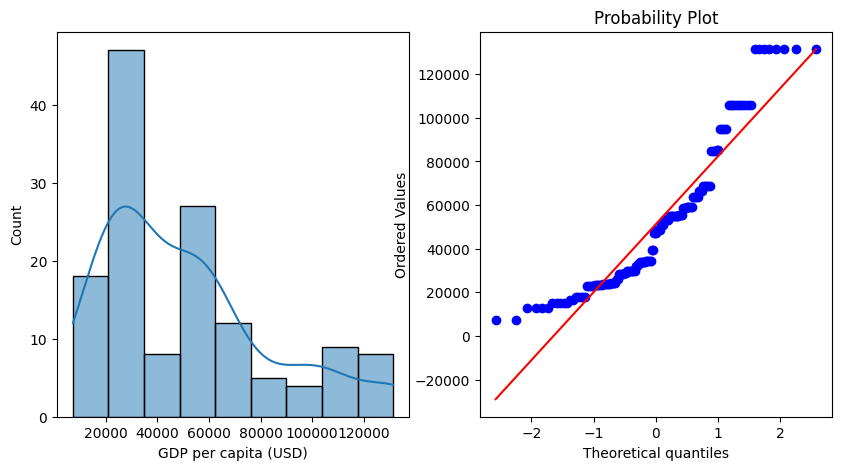

In [33]:
figure , ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['GDP per capita (USD)'], ax=ax[0],kde =True)
stats.probplot(df['GDP per capita (USD)'], plot=ax[1])

In [34]:
from sklearn.preprocessing import FunctionTransformer

In [35]:
log_trans = FunctionTransformer(np.log1p)

In [39]:
df['GDP per capita (USD)'] = log_trans.fit_transform(df['GDP per capita (USD)'])

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

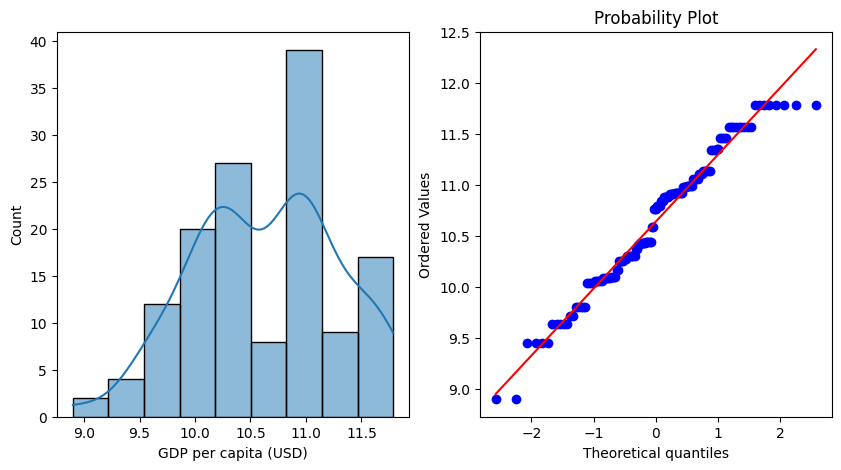

In [41]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['GDP per capita (USD)'],ax=ax[0],kde=True)
stats.probplot(df['GDP per capita (USD)'],plot=ax[1])

In [42]:
df.sample(2)

,Country,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,...,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Life expectancy,Feeling safe walking alone at night,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
26,New Zealand,10.789979,0.5,25.0,2.4,39024.0,514162.0,4.5,77,0.4,...,81.0,503.0,18.0,6.0,85,82.1,66,14.0,14.87,7.3
49,Belgium,10.924805,0.7,20.0,2.1,34884.0,447607.0,2.4,65,2.3,...,80.0,500.0,19.0,12.8,79,82.1,56,4.3,15.52,6.8


((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

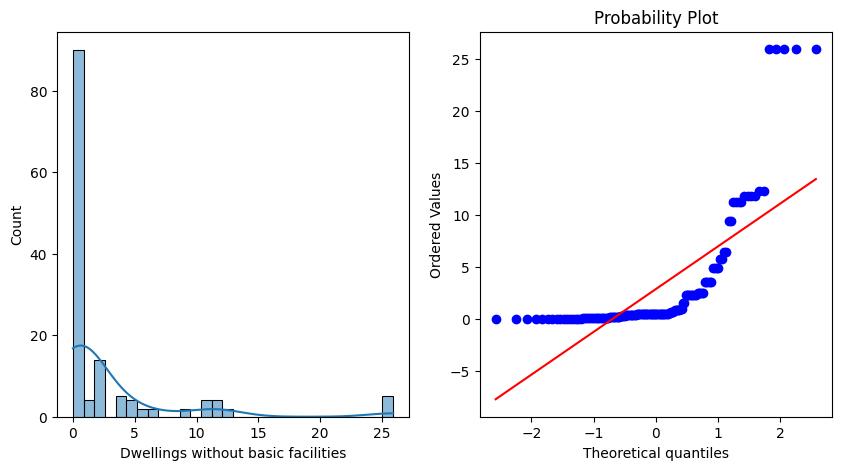

In [44]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Dwellings without basic facilities'],ax=ax[0],kde = True)
stats.probplot(df['Dwellings without basic facilities'],plot=ax[1])

In [45]:
df['Dwellings without basic facilities'] = log_trans.fit_transform(df['Dwellings without basic facilities'])

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

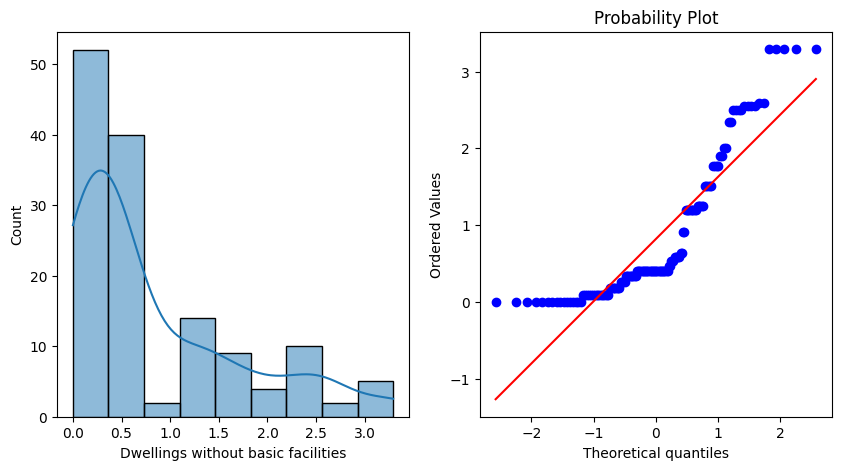

In [46]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Dwellings without basic facilities'],ax=ax[0],kde = True)
stats.probplot(df['Dwellings without basic facilities'],plot=ax[1])

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

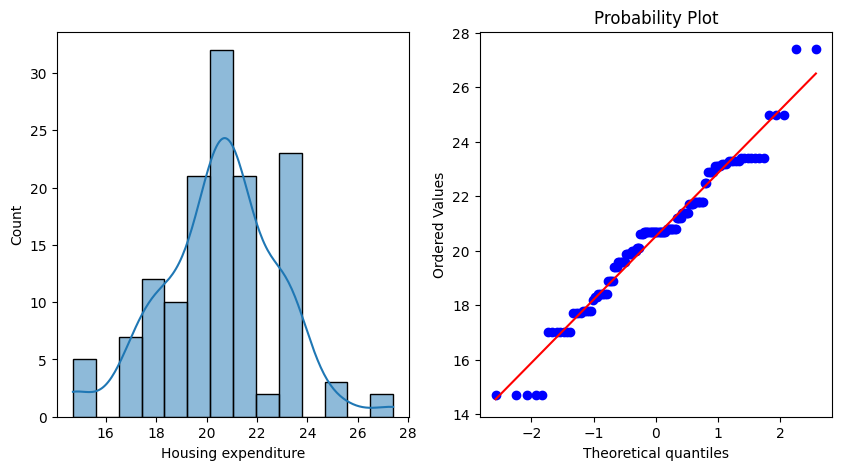

In [48]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Housing expenditure'],ax=ax[0],kde = True)
stats.probplot(df['Housing expenditure'],plot=ax[1])

#**Above graph is perfectly Normly distributed**

In [50]:
df.sample(2)

,Country,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,...,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Life expectancy,Feeling safe walking alone at night,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
108,Hungary,10.057067,1.504077,19.9,1.4,21026.0,150296.0,3.8,70,1.2,...,86.0,479.0,16.0,16.7,81,76.4,74,1.5,15.08,6.0
79,Costa Rica,9.799903,1.193922,17.0,1.2,16517.0,294735.0,3.8,55,1.5,...,43.0,415.0,18.0,17.5,87,80.5,47,22.0,14.94,6.3


((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

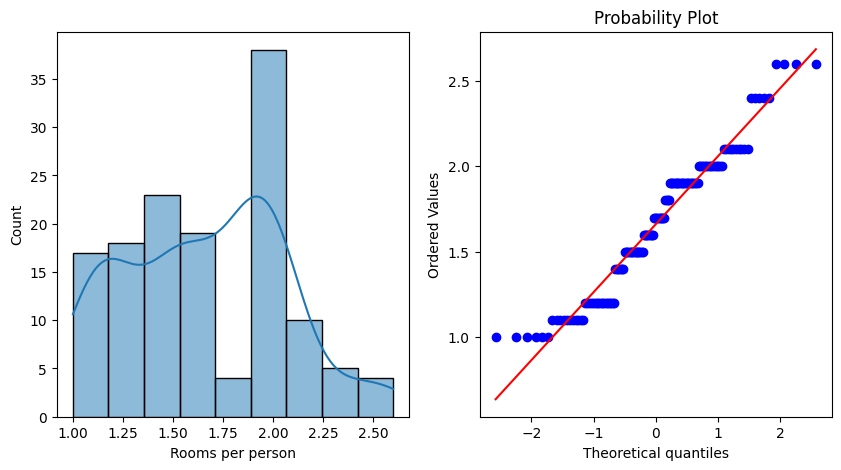

In [51]:
figure ,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Rooms per person'],ax=ax[0],kde=True)
stats.probplot(df['Rooms per person'],plot=ax[1])

In [52]:
df['Rooms per person'] = log_trans.fit_transform(df['Rooms per person'])

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

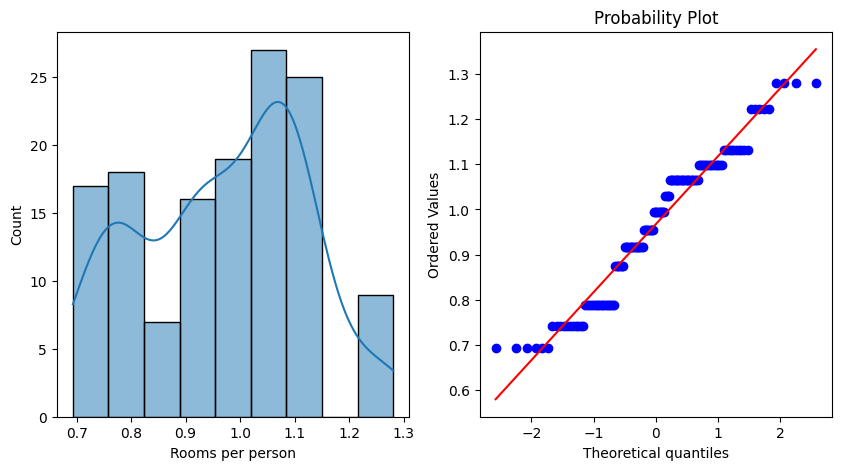

In [53]:
figure ,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Rooms per person'],ax=ax[0],kde=True)
stats.probplot(df['Rooms per person'],plot=ax[1])

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

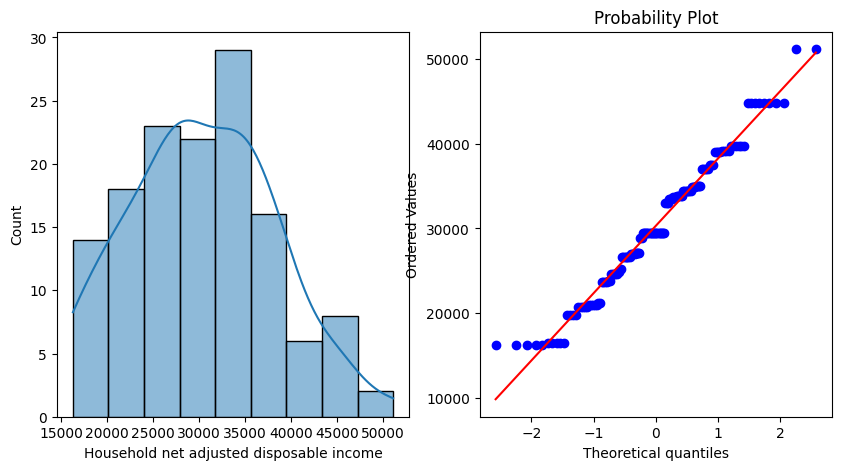

In [54]:
figure ,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Household net adjusted disposable income'],ax=ax[0],kde=True)
stats.probplot(df['Household net adjusted disposable income'],plot=ax[1])

In [55]:
df['Household net adjusted disposable income'] = log_trans.fit_transform(df['Household net adjusted disposable income'])

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

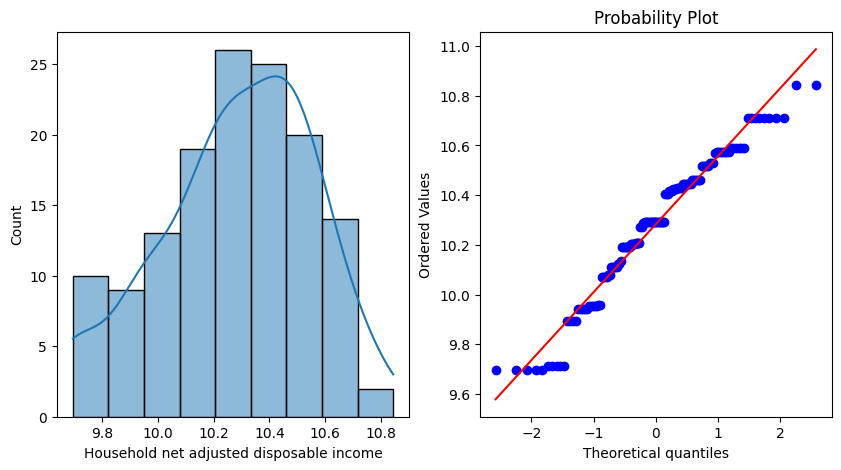

In [57]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Household net adjusted disposable income'],ax=ax[0],kde=True)
stats.probplot(df['Household net adjusted disposable income'],plot=ax[1])

In [58]:
df.sample(2)

,Country,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,...,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Life expectancy,Feeling safe walking alone at night,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
45,Finland,10.917413,0.336472,23.1,1.064711,10.418465,230032.0,2.2,72,1.2,...,91.0,516.0,20.0,5.5,97,82.1,88,3.6,15.17,7.9
87,Colombia,8.899458,2.587764,20.7,0.693147,10.291773,294735.0,3.8,58,1.1,...,59.0,406.0,14.0,22.6,82,76.7,50,23.7,14.94,5.7


((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

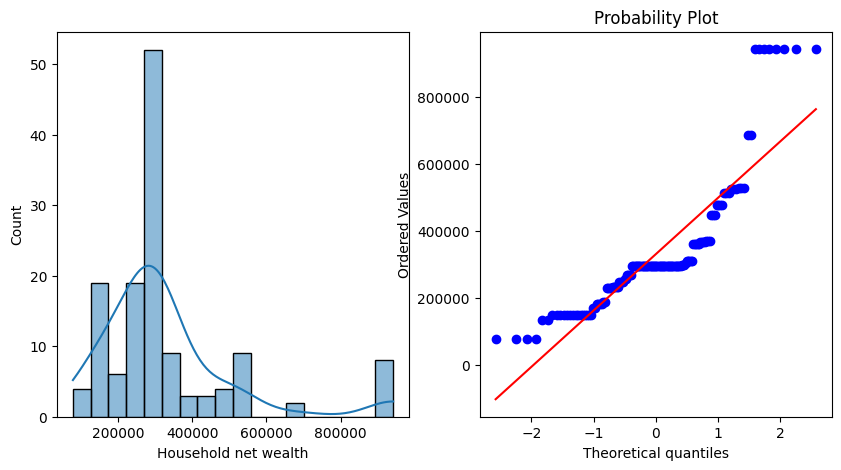

In [62]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Household net wealth'],kde=True,ax=ax[0])
stats.probplot(df['Household net wealth'],plot=ax[1])

In [63]:
df['Household net wealth'] = log_trans.fit_transform(df['Household net wealth'])

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

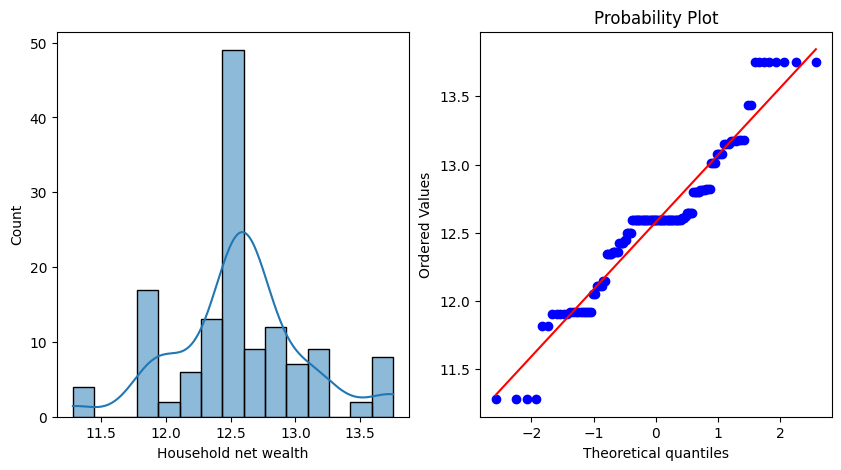

In [64]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Household net wealth'],kde=True,ax=ax[0])
stats.probplot(df['Household net wealth'],plot=ax[1])

In [65]:
df.sample(2)

,Country,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,...,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Life expectancy,Feeling safe walking alone at night,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
135,Latvia,10.093901,2.501436,20.8,0.788457,9.892629,11.280312,6.3,72,2.2,...,89.0,487.0,18.0,12.7,83,75.5,72,1.6,14.94,6.2
17,Israel,10.885060,0.405465,20.7,0.788457,10.291773,12.593835,4.6,67,0.2,...,88.0,465.0,16.0,19.7,77,82.9,80,14.1,14.94,7.2


((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

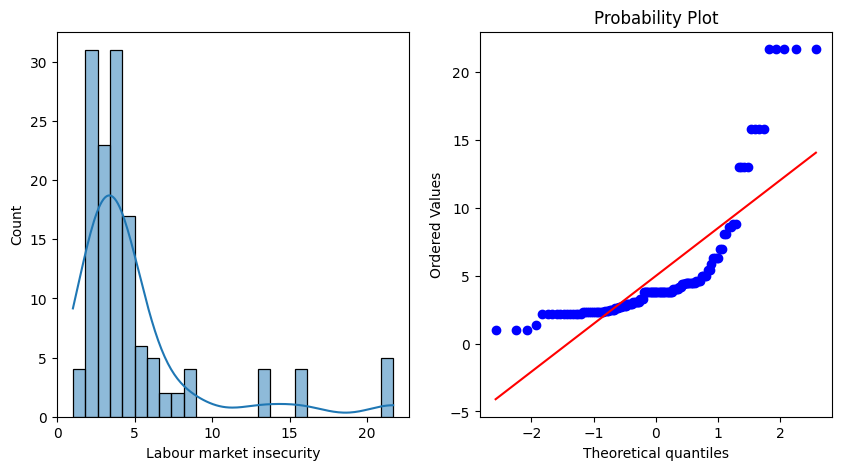

In [66]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Labour market insecurity'],kde=True,ax=ax[0])
stats.probplot(df['Labour market insecurity'],plot=ax[1])

In [67]:
df['Labour market insecurity'] = log_trans.fit_transform(df['Labour market insecurity'])

((array([-2.57512368, -2.25204016, -2.0665746 , -1.93306023, -1.82710954,
         -1.73841438, -1.66160327, -1.59350535, -1.53208528, -1.47595522,
         -1.4241245 , -1.37586007, -1.33060359, -1.28791945, -1.24746096,
         -1.20894741, -1.17214818, -1.1368713 , -1.10295521, -1.07026257,
         -1.03867554, -1.00809224, -0.97842391, -0.94959274, -0.92153007,
         -0.89417499, -0.86747319, -0.84137601, -0.81583967, -0.79082458,
         -0.76629484, -0.74221776, -0.71856347, -0.69530457, -0.67241588,
         -0.64987418, -0.62765798, -0.60574734, -0.58412374, -0.56276989,
         -0.54166964, -0.52080785, -0.50017032, -0.47974366, -0.45951526,
         -0.43947316, -0.41960608, -0.39990327, -0.38035449, -0.36095002,
         -0.34168052, -0.32253707, -0.30351111, -0.2845944 , -0.26577899,
         -0.24705721, -0.22842164, -0.20986506, -0.19138048, -0.17296106,
         -0.15460014, -0.1362912 , -0.11802783, -0.09980376, -0.08161277,
         -0.06344875, -0.04530564, -0.

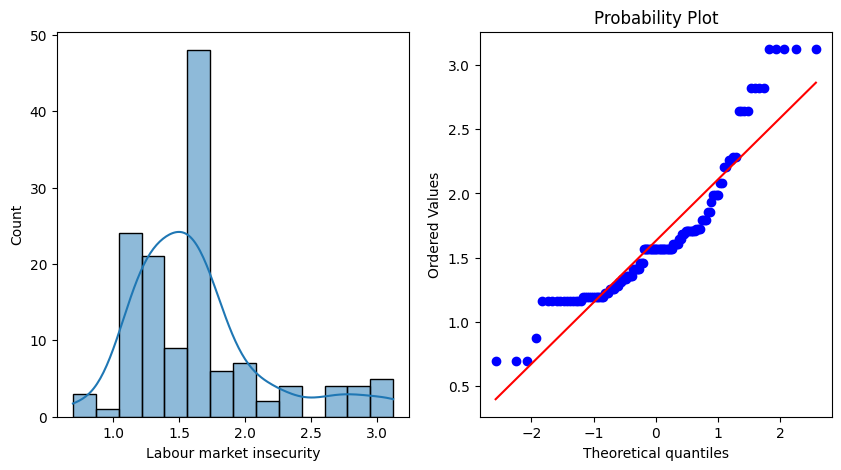

In [68]:
figure,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(df['Labour market insecurity'],kde=True,ax=ax[0])
stats.probplot(df['Labour market insecurity'],plot=ax[1])

In [76]:
cols = [
    "Household net adjusted disposable income",
    "Household net wealth",
    "Labour market insecurity",
    "Long-term unemployment rate",
    "Personal earnings",
    "Educational attainment",
    "Student skills",
    "Years in education",
    "Employees working very long hours",
    "Time devoted to leisure and personal care",
    "Dwellings without basic facilities",
    "Housing expenditure",
    "Rooms per person"
]
for col in cols:
    df[col] = log_trans.fit_transform(df[col])

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [100]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns='Life satisfaction'),df['Life satisfaction'],test_size=0.2,random_state=42)

In [104]:
numerical_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
numerical_features

Index(['GDP per capita (USD)', 'Dwellings without basic facilities',
       'Housing expenditure', 'Rooms per person',
       'Household net adjusted disposable income', 'Household net wealth',
       'Labour market insecurity', 'Employment rate',
       'Long-term unemployment rate', 'Personal earnings',
       'Quality of support network', 'Educational attainment',
       'Student skills', 'Years in education', 'Air pollution',
       'Water quality', 'Life expectancy',
       'Feeling safe walking alone at night',
       'Employees working very long hours',
       'Time devoted to leisure and personal care'],
      dtype='object')

In [105]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['GDP per capita (USD)', 'Dwellings without basic facilities',
       'Housing expenditure', 'Rooms per person',
       'Household net adjusted disposable income', 'Household net wealth',
       'Labour market insecurity', 'Employment rate',
       'Long-term unemployment rate', 'Personal earnings',
       'Quality of supp...l attainment',
       'Student skills', 'Years in education', 'Air pollution',
       'Water quality', 'Life expectancy',
       'Feeling safe walking alone at night',
       'Employees working very long hours',
       'Time devoted to leisure and personal care'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Country'], dtype='object'))])),
                ('model', LinearRegression())])

In [106]:
y_pred = pipe.predict(X_test)

In [107]:
from sklearn.metrics import mean_squared_error,r2_score

In [108]:
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)

In [109]:
r2

0.9817175824387334

In [110]:
mse

0.007227851177442056

In [112]:
from sklearn.model_selection import cross_val_score

In [113]:
score = np.mean(cross_val_score(pipe,X_train,y_train))

In [114]:
score

np.float64(0.9772279926234599)

In [115]:
import joblib

In [116]:
joblib.dump(pipe,'better-life-index-model.pkl')

['better-life-index-model.pkl']